<a href="https://colab.research.google.com/github/ManishSahani24/Quantum-Error-Correction/blob/main/Quantum_Error_Correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Encoding Qubits

The 3-bit repetition code is a classical error correcting code, but we can consider what happens if we try to use it to protect qubits against errors. As we'll see, it's not a very impressive quantum error correcting code, because it actually makes some errors more likely.

$$$$

In classical computing, if you want to protect a bit against accidental flips (like a $0$ turning into a $1$ due to noise), you can just copy it. You encode a $0$ as $000$ and a $1$ as $111$. If an error changes $000$ to $010$, you can take a "majority vote" and easily correct it back to $000$.

$$$$

However, in quantum computing, the No-Cloning Theorem says that you cannot create an identical copy of an arbitrary unknown quantum state. Therefore, if you have a qubit in a superposition $\alpha|0\rangle + \beta|1\rangle$,

you cannot just clone it to make:

 $(\alpha|0\rangle + \beta|1\rangle) \otimes (\alpha|0\rangle + \beta|1\rangle) \otimes (\alpha|0\rangle + \beta|1\rangle)$.

$$$$



 ---------------------------------------

 #### The Solution: Encoding the Basis States

  Instead of cloning the entire superposition, we apply the repetition code strictly to the standard basis states $|0\rangle$ and $|1\rangle$.

  * The logical zero state ($|0\rangle_L$) is encoded as the physical state $|000\rangle$.
  * The logical one state ($|1\rangle_L$) is encoded as the physical state $|111\rangle$.

$$$$


By spreading the information of one logical qubit across three physical qubits, you protect it against a single bit-flip error (an X-gate error).


To be clear, when we refer to the 3-bit repetition code being used for qubits, we have in mind an encoding of a qubit where **standard basis states are repeated three times**, so that a single-qubit state vector is encoded as follows.

$$\alpha|0\rangle+\beta|1\rangle\mapsto\alpha|000\rangle+\beta|111\rangle$$

This encoding can easily be achieved by the following quantum circuit.

> This is the new, 3-qubit encoded state. The original probability amplitudes ($\alpha$ and $\beta$) are perfectly preserved. However, instead of weighting single-qubit states, they now weight the 3-qubit entangled states $|000\rangle$ and $|111\rangle$.

$$$$

###### Physical Qubits ( HARDWARE )

1. A physical qubit is an actual, tangible piece of hardware in a quantum computer—like a single superconducting circuit, a trapped ion, or a single photon.

2. The problem with physical qubits is that they are extremely fragile. They are easily affected by heat, electromagnetic radiation, or slight calibration errors, which causes them to randomly flip or lose their state (decoherence).


###### Logical Qubits ( SOFTWARE )

1. A logical qubit is an abstract, idealized, mathematically perfect qubit. When we write a quantum algorithm (like Shor's algorithm), we are writing it under the assumption that our qubits are perfect and error-free.

2. Because we don't have perfect physical qubits, we have to build one logical qubit by grouping together many physical qubits.

3. Whenever the quantum algorithm asks for one perfect, error-free 'Zero' ($|0\rangle_L$), we are going to represent that in the real world using three actual physical qubits, all set to zero ($|000\rangle$).






### Entanglement is not cloning

Here we are not cloning the qubit. What we are doing in quantum error correction is creating an entangled state, not a cloned state. In the state $\alpha|000\rangle + \beta|111\rangle$, the three physical qubits are inextricably linked. The information about $\alpha$ and $\beta$ is spread out globally across the entanglement of all three qubits, rather than existing independently on each individual qubit.

In [3]:
!pip install qiskit
!pip install qiskit_ibm_runtime
!pip install qiskit_aer
!pip install matplotlib numpy pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wh

In [8]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
import numpy as np
import matplotlib.pyplot as plt
import qiskit, qiskit_ibm_runtime, qiskit_aer

In [5]:
!pip show qiskit_ibm_runtime

Name: qiskit-ibm-runtime
Version: 0.46.1
Summary: IBM Quantum client for Qiskit Runtime.
Home-page: 
Author: 
Author-email: Qiskit Development Team <qiskit@us.ibm.com>
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: ibm-platform-services, ibm-quantum-schemas, numpy, packaging, pybase64, pydantic, python-dateutil, qiskit, requests, requests-ntlm, samplomatic, urllib3
Required-by: 


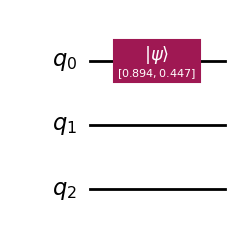

In [19]:
#Initialization of three quantum states

qc = QuantumCircuit(3)

# 2. Define arbitrary probabilities for our initial state
# Let's say alpha gives an 80% chance of 0, and beta gives a 20% chance of 1

alpha = np.sqrt(0.8)
beta = np.sqrt(0.2)

qc.initialize([alpha, beta], 0)
#qc.barrier()

qc.draw('mpl')


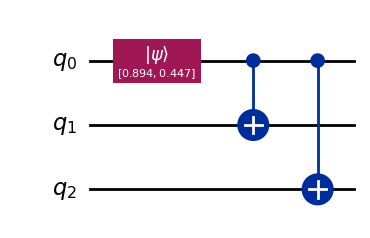

In [20]:
#applying the CNOT gate

qc.cx(0,1)
qc.cx(0,2)

qc.draw('mpl')

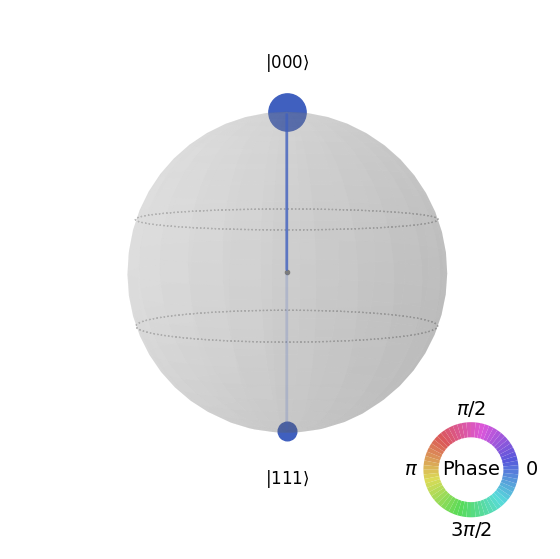

In [24]:
sv = Statevector(qc)
plot_state_qsphere(sv)


* We will notice that the final output vector only has non-zero values for the $|000\rangle$ and $|111\rangle$ states, and those values will perfectly match the $\alpha$ and $\beta$ we defined at the start.

* The initial unknown state of the single data qubit has been successfully stretched out to entangle all three physical qubits. The encoding is complete.


In [31]:
print(state.draw('text'))

[0.89442719+0.j,0.        +0.j,0.        +0.j,0.        +0.j,
 0.        +0.j,0.        +0.j,0.        +0.j,0.4472136 +0.j]


## Qubit Unitary Operations

#### Pauli Operations

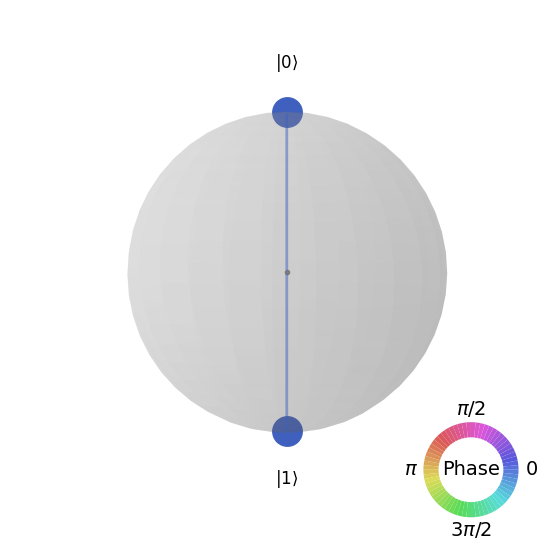

In [11]:
qc = QuantumCircuit(1)
qc.h(0)

state = Statevector.from_instruction(qc)
plot_state_qsphere(state)

##### Pauli-X (BIT FLIP)

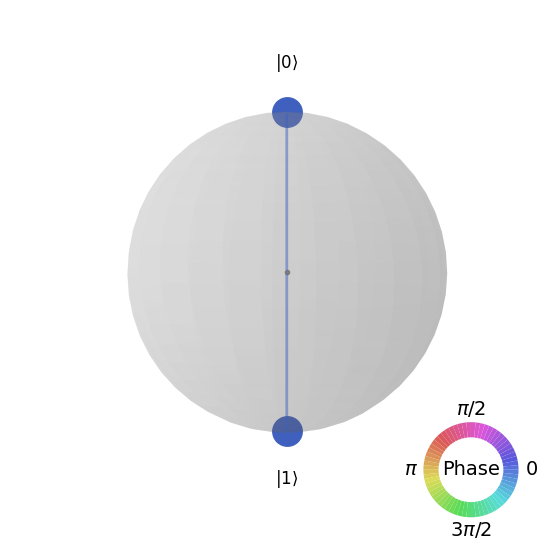

In [12]:
qc_x = QuantumCircuit(1)
qc_x.h(0)
qc_x.x(0)

state_x = Statevector.from_instruction(qc_x)
plot_state_qsphere(state_x)